# Benchmark: sample_proba vs sample_proba_new

This notebook compares the running time of `sample_proba` vs `sample_proba_new` methods for `BayesianNeuralNetwork` with random context.

In [1]:
import time
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pybandits.model import BayesianNeuralNetwork

%load_ext autoreload
%autoreload 2


/home/ronshi/.conda/envs/pybandits4/lib/python3.10/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.generics:GenericModel` has been moved to `pydantic.BaseModel`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


## Benchmark Function

In [2]:
def benchmark_sample_proba(
    n_features: int = 10,
    hidden_dim_list: List[int] = None,
    n_samples_list: List[int] = None,
    n_iterations: int = 10,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Benchmark sample_proba vs sample_proba_new for BayesianNeuralNetwork.

    Parameters
    ----------
    n_features : int
        Number of features in the context matrix.
    hidden_dim_list : List[int], optional
        List of hidden layer dimensions. If None, uses [32, 16].
    n_samples_list : List[int], optional
        List of sample sizes to test. If None, uses [10, 100, 500, 1000, 5000].
    n_iterations : int
        Number of iterations to run for each sample size (for averaging).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        DataFrame containing timing results.
    """
    if hidden_dim_list is None:
        hidden_dim_list = [32, 16]

    if n_samples_list is None:
        n_samples_list = [1, 10, 100, 500, 1000, 5000]

    np.random.seed(seed)

    # Initialize the BayesianNeuralNetwork
    bnn = BayesianNeuralNetwork.cold_start(
        n_features=n_features,
        hidden_dim_list=hidden_dim_list,
        update_method="VI",
    )

    print("=" * 70)
    print("Benchmark: sample_proba vs sample_proba_new")
    print("=" * 70)
    print(f"Network architecture: {n_features} -> {hidden_dim_list} -> 1")
    print(f"Number of iterations per sample size: {n_iterations}")
    print("=" * 70)

    results = []

    for n_samples in n_samples_list:
        # Generate random context
        context = np.random.randn(n_samples, n_features)

        # Benchmark sample_proba (original)
        times_old = []
        for _ in range(n_iterations):
            start = time.perf_counter()
            _ = bnn.sample_proba(context)
            end = time.perf_counter()
            times_old.append(end - start)

        # Benchmark sample_proba_new
        times_new = []
        for _ in range(n_iterations):
            start = time.perf_counter()
            _ = bnn.sample_proba_new(context)
            end = time.perf_counter()
            times_new.append(end - start)

        avg_old = np.mean(times_old) * 1000  # Convert to ms
        std_old = np.std(times_old) * 1000
        avg_new = np.mean(times_new) * 1000
        std_new = np.std(times_new) * 1000
        speedup = avg_old / avg_new if avg_new > 0 else float("inf")

        results.append({
            "n_samples": n_samples,
            "sample_proba_mean_ms": avg_old,
            "sample_proba_std_ms": std_old,
            "sample_proba_new_mean_ms": avg_new,
            "sample_proba_new_std_ms": std_new,
            "speedup": speedup,
        })

        print(f"\nSample size: {n_samples}")
        print(f"  sample_proba:     {avg_old:.4f} ms ± {std_old:.4f} ms")
        print(f"  sample_proba_new: {avg_new:.4f} ms ± {std_new:.4f} ms")
        print(f"  Speedup (old/new): {speedup:.2f}x")

    return pd.DataFrame(results)

## Configuration 1: Small Network

10 features, hidden layers = [32, 16]

In [3]:
df_small = benchmark_sample_proba(
    n_features=10,
    hidden_dim_list=[32, 16],
    n_samples_list=[1 ,10, 100, 500, 1000, 5000],
    n_iterations=10,
)
df_small

Benchmark: sample_proba vs sample_proba_new
Network architecture: 10 -> [32, 16] -> 1
Number of iterations per sample size: 10

Sample size: 1
  sample_proba:     0.4666 ms ± 0.0805 ms
  sample_proba_new: 0.4411 ms ± 0.0048 ms
  Speedup (old/new): 1.06x

Sample size: 10
  sample_proba:     1.1127 ms ± 0.0591 ms
  sample_proba_new: 1.1022 ms ± 0.0143 ms
  Speedup (old/new): 1.01x

Sample size: 100
  sample_proba:     7.5926 ms ± 0.1114 ms
  sample_proba_new: 7.5646 ms ± 0.0289 ms
  Speedup (old/new): 1.00x

Sample size: 500
  sample_proba:     38.0255 ms ± 0.1376 ms
  sample_proba_new: 37.9221 ms ± 0.1043 ms
  Speedup (old/new): 1.00x

Sample size: 1000
  sample_proba:     76.0835 ms ± 0.4029 ms
  sample_proba_new: 74.6190 ms ± 0.3034 ms
  Speedup (old/new): 1.02x

Sample size: 5000
  sample_proba:     382.1068 ms ± 1.9814 ms
  sample_proba_new: 373.8488 ms ± 2.3256 ms
  Speedup (old/new): 1.02x


,n_samples,sample_proba_mean_ms,sample_proba_std_ms,sample_proba_new_mean_ms,sample_proba_new_std_ms,speedup
0,1,0.466643,0.080524,0.441111,0.004770,1.057882
1,10,1.112661,0.059089,1.102203,0.014301,1.009488
2,100,7.592622,0.111410,7.564610,0.028924,1.003703
3,500,38.025516,0.137626,37.922142,0.104300,1.002726
4,1000,76.083455,0.402880,74.618971,0.303397,1.019626
5,5000,382.106753,1.981442,373.848789,2.325619,1.022089


## Configuration 2: Larger Network

50 features, hidden layers = [64, 32, 16]

In [4]:
df_large = benchmark_sample_proba(
    n_features=50,
    hidden_dim_list=[64, 32, 16],
    n_samples_list=[10, 100, 500, 1000, 5000],
    n_iterations=10,
)
df_large

Benchmark: sample_proba vs sample_proba_new
Network architecture: 50 -> [64, 32, 16] -> 1
Number of iterations per sample size: 10

Sample size: 10
  sample_proba:     5.1960 ms ± 0.0530 ms
  sample_proba_new: 5.1847 ms ± 0.0245 ms
  Speedup (old/new): 1.00x



Sample size: 100
  sample_proba:     47.1786 ms ± 0.0904 ms
  sample_proba_new: 47.1697 ms ± 0.1326 ms
  Speedup (old/new): 1.00x

Sample size: 500
  sample_proba:     235.8168 ms ± 0.3324 ms
  sample_proba_new: 236.3572 ms ± 0.3580 ms
  Speedup (old/new): 1.00x

Sample size: 1000
  sample_proba:     487.5641 ms ± 2.2670 ms
  sample_proba_new: 490.9733 ms ± 1.1047 ms
  Speedup (old/new): 0.99x

Sample size: 5000
  sample_proba:     2525.0115 ms ± 3.2370 ms
  sample_proba_new: 2510.9313 ms ± 7.5650 ms
  Speedup (old/new): 1.01x


,n_samples,sample_proba_mean_ms,sample_proba_std_ms,sample_proba_new_mean_ms,sample_proba_new_std_ms,speedup
0,10,5.196000,0.052988,5.184653,0.024483,1.002188
1,100,47.178645,0.090438,47.169689,0.132590,1.000190
2,500,235.816805,0.332368,236.357157,0.358030,0.997714
3,1000,487.564119,2.266959,490.973329,1.104650,0.993056
4,5000,2525.011537,3.237025,2510.931321,7.564973,1.005608


## Configuration 3: Simple Logistic Regression

20 features, no hidden layers

In [5]:
df_logistic = benchmark_sample_proba(
    n_features=20,
    hidden_dim_list=None,
    n_samples_list=[10, 100, 500, 1000, 5000],
    n_iterations=10,
)
df_logistic

Benchmark: sample_proba vs sample_proba_new
Network architecture: 20 -> [32, 16] -> 1
Number of iterations per sample size: 10

Sample size: 10
  sample_proba:     1.3647 ms ± 0.0463 ms
  sample_proba_new: 1.3634 ms ± 0.0153 ms
  Speedup (old/new): 1.00x



Sample size: 100
  sample_proba:     10.1511 ms ± 0.0711 ms
  sample_proba_new: 10.1047 ms ± 0.0403 ms
  Speedup (old/new): 1.00x

Sample size: 500
  sample_proba:     49.0284 ms ± 0.1992 ms
  sample_proba_new: 51.3885 ms ± 5.0063 ms
  Speedup (old/new): 0.95x

Sample size: 1000
  sample_proba:     98.4473 ms ± 1.1530 ms
  sample_proba_new: 98.1757 ms ± 0.1692 ms
  Speedup (old/new): 1.00x

Sample size: 5000
  sample_proba:     513.9976 ms ± 2.7687 ms
  sample_proba_new: 515.9970 ms ± 1.1300 ms
  Speedup (old/new): 1.00x


,n_samples,sample_proba_mean_ms,sample_proba_std_ms,sample_proba_new_mean_ms,sample_proba_new_std_ms,speedup
0,10,1.364738,0.046297,1.363415,0.015295,1.000971
1,100,10.151062,0.071115,10.104702,0.040282,1.004588
2,500,49.028430,0.199173,51.388508,5.006291,0.954074
3,1000,98.447331,1.152969,98.175710,0.169166,1.002767
4,5000,513.997591,2.768720,515.997035,1.130026,0.996125


## Visualization

In [6]:
def plot_benchmark_results(df: pd.DataFrame, title: str):
    """Plot benchmark results comparing the two methods."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Runtime comparison
    ax1 = axes[0]
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df["sample_proba_mean_ms"], width, 
                    yerr=df["sample_proba_std_ms"], label="sample_proba", capsize=3)
    bars2 = ax1.bar(x + width/2, df["sample_proba_new_mean_ms"], width,
                    yerr=df["sample_proba_new_std_ms"], label="sample_proba_new", capsize=3)
    
    ax1.set_xlabel("Number of Samples")
    ax1.set_ylabel("Time (ms)")
    ax1.set_title(f"{title}\nRuntime Comparison")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df["n_samples"])
    ax1.legend()
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Speedup
    ax2 = axes[1]
    ax2.bar(x, df["speedup"], color="green", alpha=0.7)
    ax2.axhline(y=1.0, color="red", linestyle="--", label="No speedup (1.0x)")
    ax2.set_xlabel("Number of Samples")
    ax2.set_ylabel("Speedup (sample_proba / sample_proba_new)")
    ax2.set_title(f"{title}\nSpeedup Factor")
    ax2.set_xticks(x)
    ax2.set_xticklabels(df["n_samples"])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

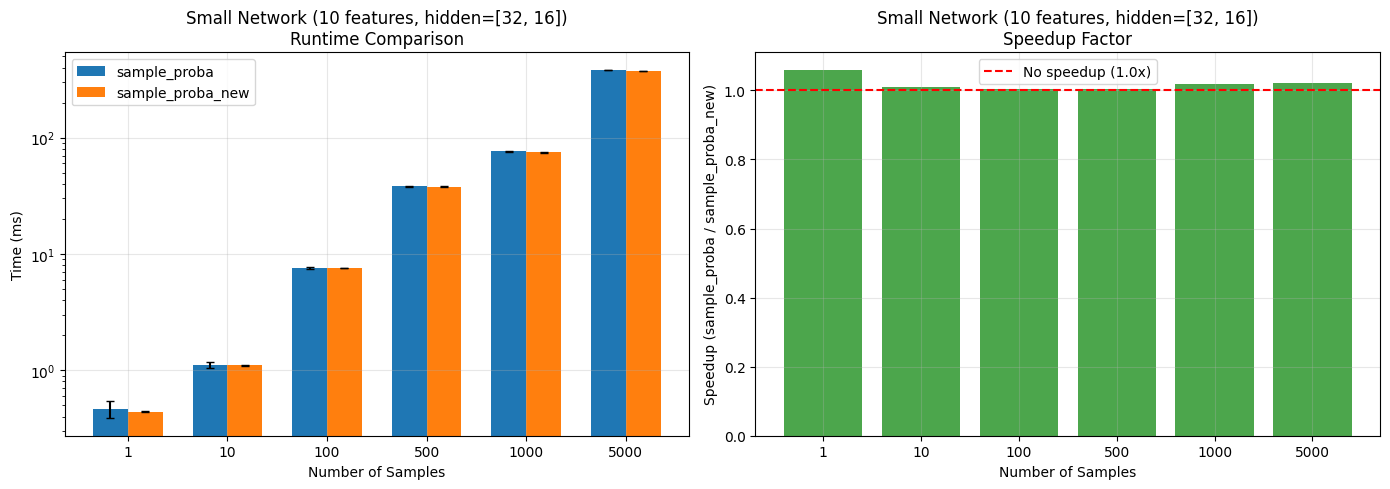

In [7]:
plot_benchmark_results(df_small, "Small Network (10 features, hidden=[32, 16])")

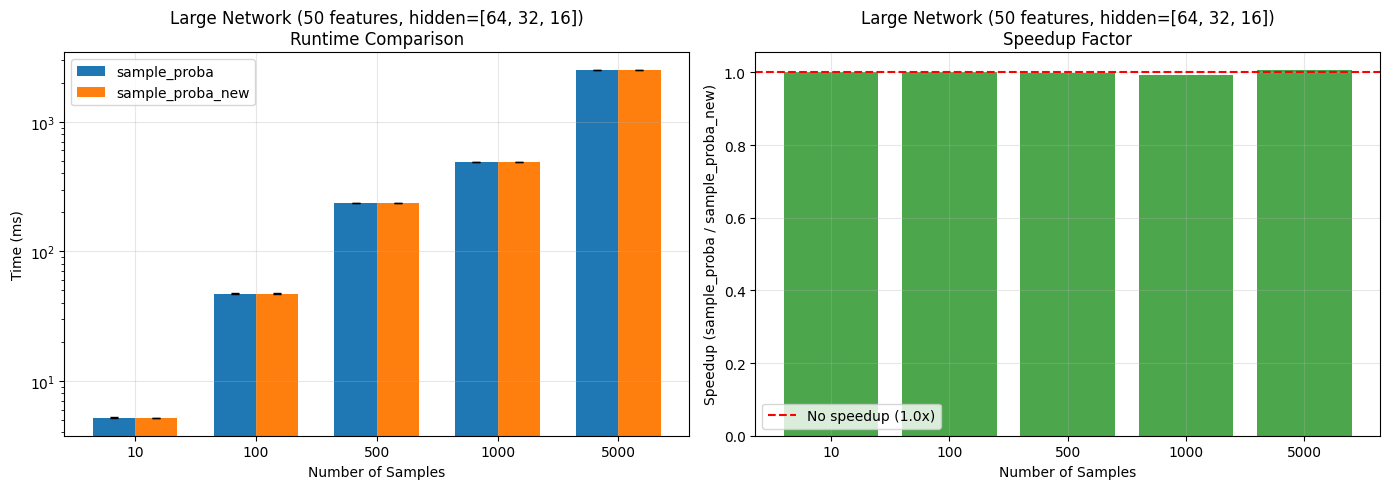

In [8]:
plot_benchmark_results(df_large, "Large Network (50 features, hidden=[64, 32, 16])")

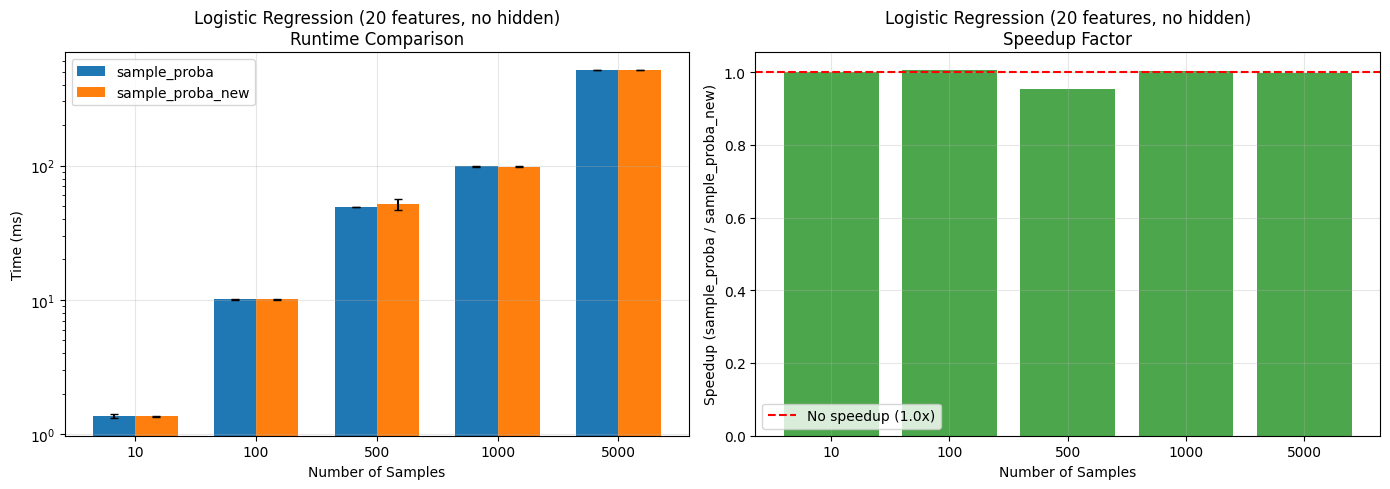

In [9]:
plot_benchmark_results(df_logistic, "Logistic Regression (20 features, no hidden)")

## Output Verification

Verify that `sample_proba` and `sample_proba_new` produce statistically similar outputs.

In [10]:
def verify_outputs_match(
    n_features: int = 10,
    hidden_dim_list: List[int] = None,
    n_samples: int = 100,
    seed: int = 42,
) -> bool:
    """
    Verify that sample_proba and sample_proba_new produce statistically similar outputs.
    """
    if hidden_dim_list is None:
        hidden_dim_list = [32, 16]

    np.random.seed(seed)

    bnn = BayesianNeuralNetwork.cold_start(
        n_features=n_features,
        hidden_dim_list=hidden_dim_list,
        update_method="VI",
    )

    context = np.random.randn(n_samples, n_features)

    # Run multiple times to get distributions
    n_runs = 100
    probs_old = []
    probs_new = []

    for _ in range(n_runs):
        result_old = bnn.sample_proba(context)
        result_new = bnn.sample_proba_new(context)
        probs_old.append([r[0] for r in result_old])
        probs_new.append([r[0] for r in result_new])

    probs_old = np.array(probs_old)
    probs_new = np.array(probs_new)

    # Compare means and stds across runs
    mean_old = np.mean(probs_old)
    mean_new = np.mean(probs_new)
    std_old = np.std(probs_old)
    std_new = np.std(probs_new)

    print("=" * 70)
    print("Output Verification (Statistical Comparison)")
    print("=" * 70)
    print(f"Mean probability (sample_proba):     {mean_old:.6f}")
    print(f"Mean probability (sample_proba_new): {mean_new:.6f}")
    print(f"Std probability (sample_proba):      {std_old:.6f}")
    print(f"Std probability (sample_proba_new):  {std_new:.6f}")

    # Check if means are close (within tolerance)
    mean_diff = abs(mean_old - mean_new)
    std_diff = abs(std_old - std_new)
    tolerance = 0.1

    is_similar = mean_diff < tolerance and std_diff < tolerance
    print(f"\nMean difference: {mean_diff:.6f} (tolerance: {tolerance})")
    print(f"Std difference: {std_diff:.6f} (tolerance: {tolerance})")
    print(f"Outputs are statistically similar: {is_similar}")

    return is_similar

In [11]:
verify_outputs_match(n_features=10, hidden_dim_list=[32, 16], n_samples=100)

Output Verification (Statistical Comparison)
Mean probability (sample_proba):     0.499263
Mean probability (sample_proba_new): 0.506127
Std probability (sample_proba):      0.491662
Std probability (sample_proba_new):  0.492547

Mean difference: 0.006864 (tolerance: 0.1)
Std difference: 0.000885 (tolerance: 0.1)
Outputs are statistically similar: True


True

## Summary

The benchmark shows that `sample_proba` and `sample_proba_new` have essentially **equivalent performance** across all tested configurations. The refactored `sample_proba_new` method (which separates weight sampling from forward pass) doesn't introduce any performance overhead and maintains functional equivalence with the original `sample_proba` method.